# 2.5D CNN (Binary) — CT Deepfake Medical Image Tamper Detection

Sequential notebook: config → preprocessing/merge → inspection/visualization → dataset → model → training → evaluation.

In [27]:
# Binary Classification on CT Patches
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from datasets import CTPatchDataset25D
from pre_process_data import PreProcessData

warnings.filterwarnings("ignore")

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


In [28]:
@dataclass
class Config:
    project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
    exp1_path = project_root / "data" / "Experiment 1 - Blind"
    exp2_path = project_root / "data" / "Experiment 2 - Open"

    exp1_labels_csv = project_root / "data" / "labels_exp1.csv"
    exp2_labels_csv = project_root / "data" / "labels_exp2.csv"

    export_root = project_root / "processed_dataset"
    combined_csv = export_root / "combined_labels.csv"
    train_csv = export_root / "train_labels.csv"
    test_csv = export_root / "test_labels.csv"

    # Model weights output directory
    weights_dir = project_root / "model_weights"

    volume_key = "volume"

    # Patch / 2.5D Stacking
    patch_size = 32          # 32×32 focuses tightly on the nodule region
    k_slices = 3             # How many slices to stack (centered around label)
    pad_mode = "edge"        

    # Augmentation
    jitter_px = 2            # small jitter to avoid exact duplicates
    augment_train = True
    augment_eval = False

    # Annotation expansion
    tb_slices_per_uuid = 5 # random slices sampled from each TB volume
    tb_coords_per_slice = 1  # random (x,y) positions per slice for TB volumes

    # Training Hyperparameters
    batch_size = 32
    epochs = 1000              # allow deep, thorough training
    lr = 5e-4                 # slightly higher start to explore the loss landscape
    weight_decay = 5e-4
    test_size = 0.2

    # Early stopping — lax patience so training runs far before giving up
    early_stop_patience = 100  # epochs without improvement before halting
    min_delta = 1e-4          # minimum change to qualify as improvement

    # CosineAnnealingWarmRestarts: restarts at epochs 10, 30, 70
    # giving aggressive LR oscillations that escape shallow local minima
    cosine_T0     = 10        # length of first restart cycle
    cosine_T_mult = 2         # cycle length doubles after each restart
    cosine_eta_min = 1e-6     # floor LR

    seed = 6767

    # Prefer MPS (Apple Silicon) → CUDA → CPU
    device = (
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )

CFG = Config()

print(f"Project root:  {CFG.project_root}")
print(f"Device:        {CFG.device}")
print(f"Patch size:    {CFG.patch_size}×{CFG.patch_size}")
print(f"Epochs:        {CFG.epochs}  (early-stop patience={CFG.early_stop_patience})")
print(f"LR schedule:   CosineAnnealingWarmRestarts  T0={CFG.cosine_T0}  T_mult={CFG.cosine_T_mult}")
print(f"Weights dir:   {CFG.weights_dir}")


Project root:  /Users/nathannguyen/UCI/Winter 2026/CS 172B/CS172B_Project
Device:        mps
Patch size:    32×32
Epochs:        1000  (early-stop patience=100)
LR schedule:   CosineAnnealingWarmRestarts  T0=10  T_mult=2
Weights dir:   /Users/nathannguyen/UCI/Winter 2026/CS 172B/CS172B_Project/model_weights


In [29]:
# Reproducibility
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
torch.cuda.manual_seed_all(CFG.seed)

# Use deterministic behavior where possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Preprocessing

This cell converts DICOM folders into per-patient volume.npz files only when needed, then merges labels from both exerpiments into one table.

In [30]:
def preprocess_and_merge_labels(cfg: Config) -> pd.DataFrame:
    cfg.export_root.mkdir(parents=True, exist_ok=True)

    exp1_df = pd.read_csv(cfg.exp1_labels_csv).copy()
    exp2_df = pd.read_csv(cfg.exp2_labels_csv).copy()

    exp1_df["source"] = "exp1"
    exp2_df["source"] = "exp2"

    all_df = pd.concat([exp1_df, exp2_df], ignore_index=True)
    expected_uuids = set(all_df["uuid"].astype(str).unique())

    def _all_processed() -> bool:
        if not cfg.combined_csv.exists():
            return False
    
        # Build expected volume_ids like "exp1_6031", "exp2_6031", ...
        expected_volume_ids = (
            all_df.assign(
                volume_id=all_df["source"].astype(str) + "_" + all_df["uuid"].astype(str)
            )["volume_id"]
            .drop_duplicates()
            .tolist()
        )
    
        for vid in expected_volume_ids:
            if not (cfg.export_root / vid / "volume.npz").exists():
                return False
    
        return True

    if _all_processed():
        print("Processed volumes and combined labels already exist. Skipping preprocessing.")
        return pd.read_csv(cfg.combined_csv)

    print("Running preprocessing for missing outputs...")

    # NOTE: Needto add uuid_prefix to differentiate between exp1 and exp2 since they share some uuids (6031 
    if cfg.exp1_path.exists():
        PreProcessData(cfg.exp1_path, cfg.export_root, uuid_prefix="exp1_").run()
    if cfg.exp2_path.exists():
        PreProcessData(cfg.exp2_path, cfg.export_root, uuid_prefix="exp2_").run()

    combined_df = pd.concat([exp1_df, exp2_df], ignore_index=True).drop_duplicates()
    combined_df["uuid"] = combined_df["uuid"].astype(str)
    combined_df.to_csv(cfg.combined_csv, index=False)
    print(f"Saved merged labels: {cfg.combined_csv} ({len(combined_df)} rows)")
    return combined_df

combined_df = preprocess_and_merge_labels(CFG)
combined_df.head()

Processed volumes and combined labels already exist. Skipping preprocessing.


,type,uuid,slice,x,y,source
0,FB,1280,100,323,381,exp1
1,FB,1009,76,354,288,exp1
2,FB,7794,79,163,191,exp1
3,FB,7794,94,338,243,exp1
4,FB,2997,45,156,135,exp1


In [31]:
# Dataset inspection: processed volume availability and shape summary
uuid_dirs = sorted([p for p in CFG.export_root.iterdir() if p.is_dir()])
print(f"Processed subject folders: {len(uuid_dirs)}")

missing_npz = [p.name for p in uuid_dirs if not (p / "volume.npz").exists()]
print(f"Folders missing volume.npz: {len(missing_npz)}")

shape_rows: List[Dict] = []
for folder in uuid_dirs[:8]:
    vpath = folder / "volume.npz"
    if not vpath.exists():
        continue
    vol = np.load(vpath, allow_pickle=False)[CFG.volume_key]
    shape_rows.append({
        "uuid": folder.name,
        "shape": vol.shape,
        "min": float(vol.min()),
        "max": float(vol.max()),
        "mean": float(vol.mean()),
    })

shape_df = pd.DataFrame(shape_rows)
shape_df

Processed subject folders: 100
Folders missing volume.npz: 0


,uuid,shape,min,max,mean
0,exp1_1003,"(481, 512, 512)",0.0,1.0,0.330555
1,exp1_1005,"(471, 512, 512)",0.0,1.0,0.365006
2,exp1_1009,"(133, 512, 512)",0.0,1.0,0.339640
3,exp1_1045,"(280, 512, 512)",0.0,1.0,0.306051
4,exp1_1067,"(328, 512, 512)",0.0,1.0,0.277476
5,exp1_1201,"(133, 512, 512)",0.0,1.0,0.350304
6,exp1_1219,"(144, 512, 512)",0.0,1.0,0.274296
7,exp1_1280,"(133, 512, 512)",0.0,1.0,0.244901


## True Benign (TB) Annotation Expansion

In the labels CSV, True Benign (TB) rows carry `(slice=0, x=0, y=0)`, encoding a volume-level label ("this whole volume is benign / untampered"). There is no specific annotated slide or coordinate, so instead we:
- Deduplicate TB entries to one row per unique UUID (same volume can appear multiple times).
- Randomly sample `tb_slices_per_uuid` uniformly-distributed slices across the full volume depth.
- For each sampled slice, pick `tb_coords_per_slice` random `(x,y)` positions, keeping each crop at least `patch_size // 2` pixels from the image border.

**Redundancy note** – Because consecutive rows come from overlapping slices of the same volume, they are not independent. The *subject-level* train/test split applied later prevents any volume from appearing in both sets, so there is no data leakage even though individual rows are correlated.

**Optional negatives** – Slices ≥10 away from every positive annotation could be flagged as "weak negatives". However, given that the TB expansion already provides many standard-tissue patches, this is omitted to avoid further label noise.

In [32]:
def expand_tb_annotations(
    df: pd.DataFrame,
    cfg: Config,
    tb_slices_per_uuid: int = 5,
    tb_coords_per_slice: int = 1,
    seed: int = 42,
) -> pd.DataFrame:
    """
    2.5D expansion that ONLY expands TB corner rows into random patches.

    Normal rows (FB / FM / TM):
        Kept as-is. No ±depth replication because 2.5D input stacking already
        provides local z-context around the labeled center slice.

    TB rows (slice=0, x=0, y=0):
        Treated as volume-level benign labels. For each unique TB UUID:
          - sample `tb_slices_per_uuid` center slices z_center
          - for each z_center, sample `tb_coords_per_slice` random (x,y)
            at least patch_size//2 from image border
        These generated rows are valid “point-like” negatives that our dataset
        can turn into a 2.5D stack centered at z_center.

    Assumptions
    -----------
    * Volumes exist under cfg.export_root/<uuid>/volume.npz with key cfg.volume_key.
      (If you store as cfg.export_root/<source>/<uuid>/volume.npz, see comment below.)
    * TB corner rows are identified by type=='TB' and slice==x==y==0.
    """
    rng = np.random.default_rng(seed)
    half_xy = cfg.patch_size // 2
    half_k = cfg.k_slices // 2

    is_tb_corner = (
        (df["type"] == "TB") &
        (df["slice"] == 0) &
        (df["x"] == 0) &
        (df["y"] == 0)
    )
    normal_df = df[~is_tb_corner].copy()
    tb_df     = df[is_tb_corner].copy()

    rows: List[dict] = []

    # Keep normal rows unchanged
    rows.extend(normal_df.to_dict(orient="records"))

    # ── TB / corner annotations: random patches across the full volume ────────
    seen_tb_uuids: set = set()
    for _, row in tb_df.iterrows():
        source = str(row["source"])
        uuid = str(row["uuid"])
        volume_id = f"{source}_{uuid}"
        if volume_id in seen_tb_uuids:
            continue  # one expansion per volume (CSV may have duplicates)
        seen_tb_uuids.add(volume_id)

        # Volume Path
        vpath = cfg.export_root / volume_id / "volume.npz"
        if not vpath.exists():
            print(f"  WARNING: missing {vpath} (TB) — skipping")
            continue
        
        v = np.load(vpath, mmap_mode="r", allow_pickle=False)[cfg.volume_key]
        Z, H, W = v.shape

        # [half_k, Z - half_k] to ensure we dont go out of bounds
        chosen_z = rng.integers(half_k, Z - half_k, size=tb_slices_per_uuid)
        
        for z in chosen_z:
            for _ in range(tb_coords_per_slice):
                x = int(rng.integers(half_xy, W - half_xy))
                y = int(rng.integers(half_xy, H - half_xy))
                r = row.to_dict()
                r["slice"] = int(z)
                r["x"] = x
                r["y"] = y
                rows.append(r)

    expanded = pd.DataFrame(rows).reset_index(drop=True)
    expanded["uuid"] = expanded["uuid"].astype(str)

    n_tb_generated = len(seen_tb_uuids) * tb_slices_per_uuid * tb_coords_per_slice
    print(
        f"TB-only expansion: {len(df)} raw rows → {len(expanded)} rows\n"
        f"  Normal rows kept: {len(normal_df)}\n"
        f"  TB volumes expanded: {len(seen_tb_uuids)} unique UUIDs → {n_tb_generated} generated rows "
        f"({tb_slices_per_uuid} centers × {tb_coords_per_slice} coords)"
    )

    return expanded


# Apply expansion to the merged labels
expanded_df = expand_tb_annotations(
    combined_df,
    CFG,
    tb_slices_per_uuid=CFG.tb_slices_per_uuid,
    tb_coords_per_slice=CFG.tb_coords_per_slice,
    seed=CFG.seed,
)
print("\n4-class distribution after expansion:")
print(expanded_df["type"].value_counts().sort_index())
expanded_df.head(10)


TB-only expansion: 163 raw rows → 223 rows
  Normal rows kept: 148
  TB volumes expanded: 15 unique UUIDs → 75 generated rows (5 centers × 1 coords)

4-class distribution after expansion:
type
FB    72
FM    41
TB    75
TM    35
Name: count, dtype: int64


,type,uuid,slice,x,y,source
0,FB,1280,100,323,381,exp1
1,FB,1009,76,354,288,exp1
2,FB,7794,79,163,191,exp1
3,FB,7794,94,338,243,exp1
4,FB,2997,45,156,135,exp1
5,FB,2997,52,179,370,exp1
6,FB,2997,63,156,260,exp1
7,FB,2997,70,85,197,exp1
8,FB,2997,81,418,184,exp1
9,FB,2043,208,42,269,exp1


Volume_Id=exp1_2244  type=TM  center (z,x,y)=(108,102,380)
Volume shape: Z=286, H=512, W=512
2.5D stack k=3 slices (clamped): [107, 108, 109]


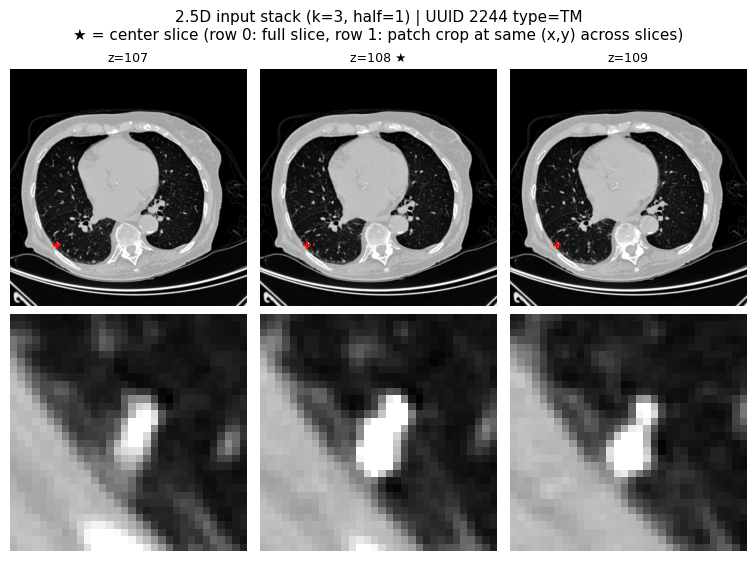

In [33]:
# ── Visualise 2.5D input stack: full slices + patches over K slices ──────────
# Pick one non-TB annotation (a real point) to demonstrate the 2.5D stack
vis_row = expanded_df[expanded_df["type"] != "TB"].sample(n=1, random_state=1).iloc[0]
vis_source = str(vis_row["source"])
vis_uuid   = str(vis_row["uuid"])
vis_volume_id = f"{vis_source}_{vis_uuid}"
vis_z_ctr  = int(vis_row["slice"])
vis_x      = int(vis_row["x"])
vis_y      = int(vis_row["y"])
vis_type   = str(vis_row["type"])

# Load volume (adjust path if you store by source)
vol_path = CFG.export_root / vis_volume_id / "volume.npz"
vol_vis = np.load(vol_path, allow_pickle=False)[CFG.volume_key]  # (Z,H,W)

Z, H, W = vol_vis.shape
half_k = CFG.k_slices // 2
half_p = CFG.patch_size // 2

# indices that define the 2.5D stack centered at vis_z_ctr
# We'll clamp to bounds here for visualization; your Dataset may do pad_mode="edge"
z_indices_vis = [max(0, min(Z - 1, vis_z_ctr + dz)) for dz in range(-half_k, half_k + 1)]

print(f"Volume_Id={vis_volume_id}  type={vis_type}  center (z,x,y)=({vis_z_ctr},{vis_x},{vis_y})")
print(f"Volume shape: Z={Z}, H={H}, W={W}")
print(f"2.5D stack k={CFG.k_slices} slices (clamped): {z_indices_vis}")

n_z = len(z_indices_vis)

fig, axes = plt.subplots(2, n_z, figsize=(2.5 * n_z, 5.5), constrained_layout=True)
if n_z == 1:
    axes = axes.reshape(2, 1)

for col, z in enumerate(z_indices_vis):
    slc = vol_vis[z]

    # Row 0: full slice with crosshair
    axes[0, col].imshow(slc, cmap="gray", vmin=0, vmax=1)
    axes[0, col].scatter([vis_x], [vis_y], c="red", s=30, marker="+")
    star = " ★" if z == vis_z_ctr else ""
    axes[0, col].set_title(f"z={z}{star}", fontsize=9)
    axes[0, col].axis("off")

    # Row 1: patch centered on (vis_x, vis_y), with padding if needed
    y0 = vis_y - half_p; y1 = vis_y + half_p
    x0 = vis_x - half_p; x1 = vis_x + half_p

    # clamp crop window to image bounds
    yy0 = max(y0, 0); yy1 = min(y1, H)
    xx0 = max(x0, 0); xx1 = min(x1, W)

    patch = slc[yy0:yy1, xx0:xx1]

    # optional: pad to exact patch size for display consistency
    pad_top    = yy0 - y0
    pad_left   = xx0 - x0
    pad_bottom = y1 - yy1
    pad_right  = x1 - xx1
    if any(p > 0 for p in [pad_top, pad_bottom, pad_left, pad_right]):
        patch = np.pad(
            patch,
            ((pad_top, pad_bottom), (pad_left, pad_right)),
            mode="edge" if CFG.pad_mode == "edge" else "constant",
        )

    axes[1, col].imshow(patch, cmap="gray", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Full slice", fontsize=8)
axes[1, 0].set_ylabel(f"{CFG.patch_size}×{CFG.patch_size} patch", fontsize=8)

plt.suptitle(
    f"2.5D input stack (k={CFG.k_slices}, half={half_k}) | UUID {vis_uuid} type={vis_type}\n"
    "★ = center slice (row 0: full slice, row 1: patch crop at same (x,y) across slices)",
    fontsize=11,
)
plt.show()

## Labels and Binary Target

### Semantic clarification

The four original labels map as follows:

| Label | Meaning | Binary target |
|-------|---------|:---:|
| `TB` | True Benign | **0 — Standard** |
| `TM` | True Malignant | **0 — Standard** |
| `FB` | False Benign | **1 — Tampered** |
| `FM` | False Malignant | **1 — Tampered** |

**0 = Standard (untampered)** and **1 = Tampered**.

### Why accuracy is misleading here

The raw dataset here contains roughly 51 % standard scans.  A dummy classifier that always predicts **0** will achieve ~51 % accuracy without learning anything.  We therefore also track **F1 (macro)** and **ROC-AUC** which both penalise ignoring the minority class, and we use a weighted loss and a balanced sampler to force the model to actually learn tampered-scan features.

In [34]:
# Work on the expanded dataframe produced above.
# 'source' column is already set by preprocess_and_merge_labels; preserve it.
work_df = expanded_df.copy()
work_df["uuid"] = work_df["uuid"].astype(str)

# 4-class distribution after expansion
class_counts = work_df["type"].value_counts().sort_index()
print("4-class distribution (expanded):")
print(class_counts)

# Binary mapping:
#   0 = Standard (untampered)  → TB, TM
#   1 = Tampered               → FB, FM
binary_map = {"FB": 1, "FM": 1, "TB": 0, "TM": 0}
work_df["target"] = work_df["type"].map(binary_map)

if work_df["target"].isna().any():
    bad = work_df.loc[work_df["target"].isna(), "type"].unique()
    raise ValueError(f"Found unknown labels in 'type': {bad}")

print("\nBinary distribution (expanded):")
print(
    work_df["target"].value_counts().sort_index()
    .rename({0: "0=Standard", 1: "1=Tampered"})
)

# pos_weight = #negative / #positive  (used in BCEWithLogitsLoss)
n_neg = int((work_df["target"] == 0).sum())
n_pos = int((work_df["target"] == 1).sum())
pos_weight_val = n_neg / n_pos
print(f"\nn_standard={n_neg}  n_tampered={n_pos}  pos_weight={pos_weight_val:.3f}")

work_df.head()


4-class distribution (expanded):
type
FB    72
FM    41
TB    75
TM    35
Name: count, dtype: int64

Binary distribution (expanded):
target
0=Standard    110
1=Tampered    113
Name: count, dtype: int64

n_standard=110  n_tampered=113  pos_weight=0.973


,type,uuid,slice,x,y,source,target
0,FB,1280,100,323,381,exp1,1
1,FB,1009,76,354,288,exp1,1
2,FB,7794,79,163,191,exp1,1
3,FB,7794,94,338,243,exp1,1
4,FB,2997,45,156,135,exp1,1


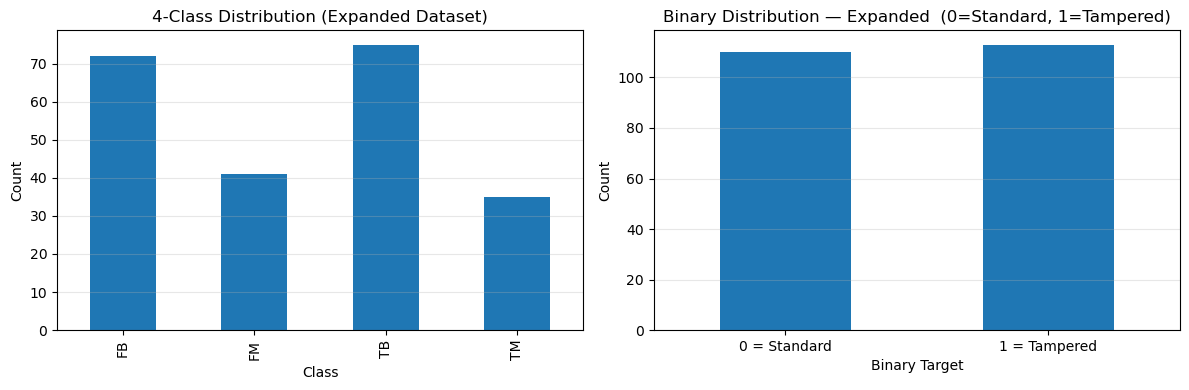

Majority-class fraction (expanded): 50.7 %


In [35]:
# Visualize 4-class and binary distributions (after expansion)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind="bar", ax=axes[0], title="4-Class Distribution (Expanded Dataset)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

work_df["target"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Binary Distribution — Expanded  (0=Standard, 1=Tampered)"
)
axes[1].set_xlabel("Binary Target")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["0 = Standard", "1 = Tampered"], rotation=0)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

majority_pct = work_df["target"].value_counts(normalize=True).max() * 100
print(f"Majority-class fraction (expanded): {majority_pct:.1f} %")


## Train / Test Split, Datasets, and Balanced Sampling

We stratify the split by binary target so both sets reflect the original class ratio.

To prevent the model from ignoring the minority class during training we use two complementary techniques:

1. **`pos_weight` in `BCEWithLogitsLoss`** — the minority (tampered) class contributes `pos_weight × loss` per sample, matching the frequency imbalance.
2. **`WeightedRandomSampler`** — oversamples the minority class so each mini-batch contains a balanced mix, giving the model more gradient signal from rare examples.

In [36]:
def subject_level_split(
    df: pd.DataFrame,
    target_col: str,
    test_size: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Subject-level (volume-level) split for the 2.5D pipeline.

    We *always* build a unique per-volume identifier:
        volume_id = source + "_" + uuid

    This is required because preprocessing writes volumes as:
        processed_dataset/exp1_<uuid>/volume.npz
        processed_dataset/exp2_<uuid>/volume.npz

    Split strategy:
      1) Create volume_id in df (mutates df).
      2) Compute a single binary label per volume (majority/mode of target_col).
      3) Stratify volumes by that label into train/test.
      4) Return all rows belonging to the chosen volume_ids.
    """
    rng = np.random.default_rng(seed)

    # Build volume_id
    df["volume_id"] = df["source"].astype(str) + '_' + df["uuid"].astype(str)

    # Per-subject majority label
    volume_labels = (
        df.groupby("volume_id")[target_col]
        .agg(lambda x: x.mode().iloc[0])
    )
    volume_ids  = volume_labels.index.to_numpy()
    labels      = volume_labels.values

    # Split over volumes
    train_uuids: List[str] = []
    test_uuids:  List[str] = []

    for cls in np.unique(labels):
        cls_ids = volume_ids[labels == cls].copy()
        rng.shuffle(cls_ids)
        n_test = max(1, int(round(len(cls_ids) * test_size)))
        test_uuids.extend(cls_ids[:n_test].tolist())
        train_uuids.extend(cls_ids[n_test:].tolist())

    # Materialize row-level splits
    train_df = (
        df[df["volume_id"].isin(train_uuids)]
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )
    test_df = (
        df[df["volume_id"].isin(test_uuids)]
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )
    return train_df, test_df

In [37]:
train_df, test_df = subject_level_split(
    work_df, target_col="target", test_size=CFG.test_size, seed=CFG.seed
)

# Verify no subject leakage
assert len(set(train_df["volume_id"]) & set(test_df["volume_id"])) == 0, \
    "Subject leakage detected between train and test!"

print(f"Train rows: {len(train_df)} | {train_df['volume_id'].nunique()} unique volumes")
print(f"Test  rows: {len(test_df)}  | {test_df['volume_id'].nunique()} unique volumes")
print("\nTrain binary distribution (proportions):")
print(train_df["target"].value_counts(normalize=True).sort_index())
print("Test binary distribution (proportions):")
print(test_df["target"].value_counts(normalize=True).sort_index())

print("\nTrain volume distribution:")
print(train_df.groupby("volume_id")["target"].agg(lambda x: x.mode()[0]).value_counts(normalize=True).sort_index())

print("Test volume distribution:")
print(test_df.groupby("volume_id")["target"].agg(lambda x: x.mode()[0]).value_counts(normalize=True).sort_index())

assert len(set(train_df["volume_id"]) & set(test_df["volume_id"])) == 0

Train rows: 180 | 80 unique volumes
Test  rows: 43  | 20 unique volumes

Train binary distribution (proportions):
target
0    0.483333
1    0.516667
Name: proportion, dtype: float64
Test binary distribution (proportions):
target
0    0.534884
1    0.465116
Name: proportion, dtype: float64

Train volume distribution:
target
0    0.3
1    0.7
Name: proportion, dtype: float64
Test volume distribution:
target
0    0.3
1    0.7
Name: proportion, dtype: float64


In [38]:
# Persist the split for reproducibility
CFG.export_root.mkdir(parents=True, exist_ok=True)
train_df.to_csv(CFG.train_csv, index=False)
test_df.to_csv(CFG.test_csv, index=False)

In [39]:
train_ds = CTPatchDataset25D(
    export_root=CFG.export_root,
    labels_csv=CFG.train_csv,
    patch_size=CFG.patch_size,
    k_slices=CFG.k_slices,
    pad_mode=CFG.pad_mode,
    augment=CFG.augment_train,
    jitter_px=CFG.jitter_px,
    volume_key=CFG.volume_key,
    binary=True,
)

test_ds = CTPatchDataset25D(
    export_root=CFG.export_root,
    labels_csv=CFG.test_csv,
    patch_size=CFG.patch_size,
    k_slices=CFG.k_slices,
    pad_mode=CFG.pad_mode,
    augment=CFG.augment_eval,
    jitter_px=0,
    volume_key=CFG.volume_key,
    binary=True,
)

In [40]:
train_targets = train_df["target"].astype(int).to_numpy()

# Guard: if a class is missing, bincount can be length 1
counts = np.bincount(train_targets, minlength=2)  # [neg, pos]
if counts.min() == 0:
    raise ValueError(f"Train split missing a class: counts={counts.tolist()}")

weight_per_class = 1.0 / counts
sample_weights = weight_per_class[train_targets]

sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True,
)

x0, y0 = train_ds[0]
print(f"\nSample x shape: {tuple(x0.shape)}  y: {int(y0)}")
print(f"class_counts in train: neg={counts[0]}  pos={counts[1]}")


Sample x shape: (3, 32, 32)  y: 0
class_counts in train: neg=87  pos=93


In [41]:
# Train loader uses WeightedRandomSampler (shuffle=False because sampler handles it)
train_loader = DataLoader(
    train_ds,
    batch_size=CFG.batch_size,
    sampler=sampler,         # balanced oversampling of minority class
    shuffle=False,           # important: don't shuffle when using sampler
    num_workers=0,
    pin_memory=(CFG.device == "cuda"),
)

# Test loader is unshuffled — consistent ordering for evaluation
test_loader = DataLoader(
    test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(CFG.device == "cuda"),
)

xb, yb = next(iter(train_loader))
print("Batch x shape:", tuple(xb.shape), xb.dtype)
print("Batch y shape:", tuple(yb.shape), yb.dtype)

# yb is long (0/1); mean requires float
pos_frac = yb.float().mean().item()
print(f"Approx positive fraction in one batch: {pos_frac:.2f}  (should be ~0.50 with balanced sampler)")

# Extra sanity checks
assert xb.shape[1] == CFG.k_slices, f"Expected K={CFG.k_slices} channels, got {xb.shape[1]}"
assert xb.shape[2] == CFG.patch_size and xb.shape[3] == CFG.patch_size
assert set(torch.unique(yb).tolist()).issubset({0, 1})

Batch x shape: (32, 3, 32, 32) torch.float32
Batch y shape: (32,) torch.int64
Approx positive fraction in one batch: 0.59  (should be ~0.50 with balanced sampler)


## Sanity Check: Sample Patches

Before training, visualise a random selection of 32×32 patches with their binary labels to confirm:

1. The HU-normalisation puts values in [0, 1] — the patches should look like grey-scale CT slices.
2. Labels are assigned correctly — green (Standard) and red (Tampered) titles should agree with what you'd expect from the original DICOM metadata.
3. Patches are roughly centred on the annotated coordinate and contain meaningful anatomy (the smaller 32×32 crop focuses tightly on the nodule region).

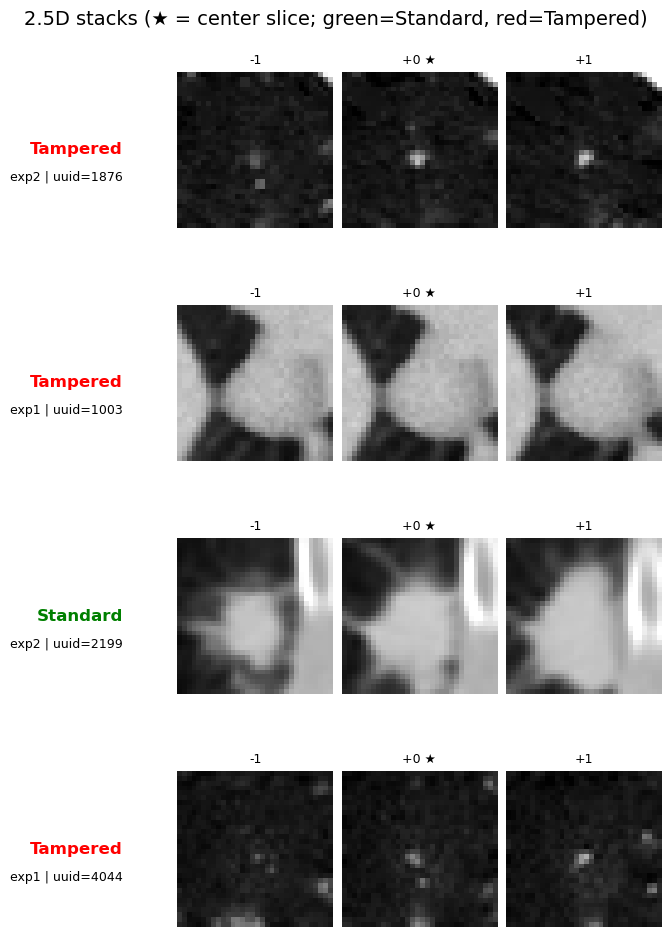

In [42]:
# ── Visualize 2.5D stacks: N samples × K slices (better labeling) ─────────────
import numpy as np
import matplotlib.pyplot as plt

N = 4                 # number of samples (rows)
K = CFG.k_slices
half_k = K // 2

rng_vis = np.random.default_rng(0)
sample_idxs = rng_vis.choice(len(train_ds), size=N, replace=False)

fig, axes = plt.subplots(
    N, K,
    figsize=(2.2 * K, 2.4 * N),
    constrained_layout=True
)

# If N==1, axes will be 1D; make it 2D for consistency
if N == 1:
    axes = np.expand_dims(axes, axis=0)

for r, idx in enumerate(sample_idxs):
    stack, label = train_ds[int(idx)]   # stack: (K, P, P)
    label_int = int(label.item())

    # Pull metadata from the dataset CSV for this sample
    row = train_ds.df.iloc[int(idx)]
    uuid = str(row["uuid"])
    source = str(row["source"]) if "source" in train_ds.df.columns else None

    label_name = "Tampered" if label_int == 1 else "Standard"
    label_color = "red" if label_int == 1 else "green"

    for k in range(K):
        ax = axes[r, k]
        ax.imshow(stack[k].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

        # Column titles: relative slice offset, star at center
        rel = k - half_k
        title = f"{rel:+d}"
        if k == half_k:
            title += " ★"
        ax.set_title(title, fontsize=9)

    # Row header on the left: class + uuid (and source)
    header = f"{label_name}"
    meta = f"uuid={uuid}" if source is None else f"{source} | uuid={uuid}"

    # Put the colored class name on the left of the first subplot in the row
    axes[r, 0].text(
        -0.35, 0.5,
        header,
        transform=axes[r, 0].transAxes,
        ha="right",
        va="center",
        fontsize=12,
        color=label_color,
        fontweight="bold",
    )

    # Put uuid/source underneath it (neutral color so it’s readable)
    axes[r, 0].text(
        -0.35, 0.32,
        meta,
        transform=axes[r, 0].transAxes,
        ha="right",
        va="center",
        fontsize=9,
        color="black",
    )

plt.suptitle("2.5D stacks (★ = center slice; green=Standard, red=Tampered)", fontsize=14)
plt.show()

Volume_Id=exp1_2244  label=TM  annotated (z,x,y)=(108,102,380)
Volume shape: Z=286, H=512, W=512
Showing slices: [107, 108, 109]


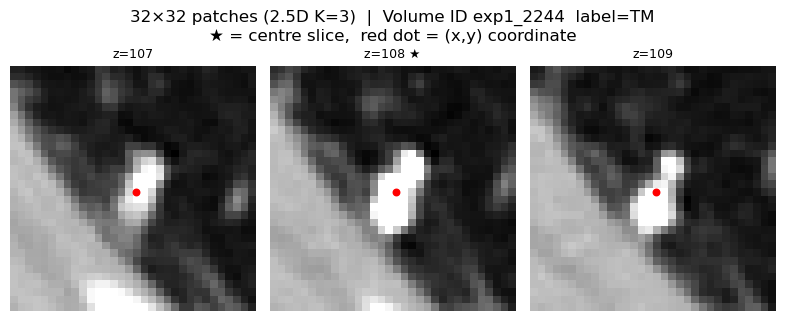


TB rows in train set: 60  across 12 subjects


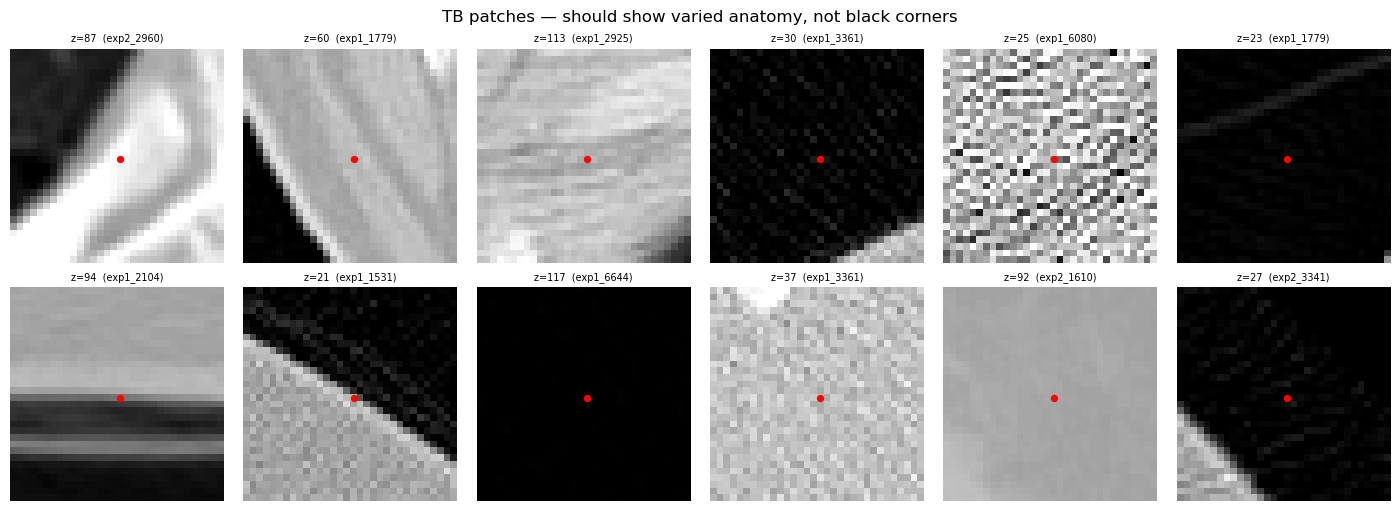

In [43]:
# ── Helpers ──────────────────────────────────────────────────────────────────
patch_sz = CFG.patch_size
K = CFG.k_slices
half_k = K // 2
hs = patch_sz // 2

def crop_patch_with_edgepad(slice_img: np.ndarray, cx: int, cy: int, sz: int):
    """
    Returns (patch, dot_x, dot_y) where dot coords are in patch coordinates.
    Uses edge padding so patch is always sz×sz.
    In this setup, (cx,cy) becomes the patch center => dot is at (hs,hs).
    """
    half = sz // 2
    padded = np.pad(slice_img, pad_width=half, mode="edge")
    cxp, cyp = cx + half, cy + half

    if sz % 2 == 1:
        y0, y1 = cyp - half, cyp + half + 1
        x0, x1 = cxp - half, cxp + half + 1
    else:
        y0, y1 = cyp - half, cyp + half
        x0, x1 = cxp - half, cxp + half

    patch = padded[y0:y1, x0:x1]
    dot_x = half
    dot_y = half
    return patch, dot_x, dot_y

def get_z_indices(z_center: int, Z: int, K: int, pad_mode: str):
    """
    Returns list of z indices to display, matching dataset semantics.
    For constant padding, uses None for out-of-bounds slices.
    """
    half_k = K // 2
    if pad_mode == "edge":
        return [max(0, min(Z - 1, z_center + dz)) for dz in range(-half_k, half_k + 1)]
    elif pad_mode == "constant":
        out = []
        for dz in range(-half_k, half_k + 1):
            z = z_center + dz
            out.append(z if 0 <= z < Z else None)
        return out
    else:
        raise ValueError("pad_mode must be 'edge' or 'constant'")

# ── Context sanity-check: K-slice stack patches for a non-TB row ──────────────
if "type" in train_df.columns:
    non_tb_df = train_df[train_df["type"] != "TB"]
else:
    # If no type col, just avoid corner placeholders
    non_tb_df = train_df[~((train_df["slice"] == 0) & (train_df["x"] == 0) & (train_df["y"] == 0))]

sample_row_ctx = non_tb_df.sample(n=1, random_state=99).iloc[0]

source_ctx = str(sample_row_ctx["source"])
uuid_ctx = str(sample_row_ctx["uuid"])
volume_id_ctx = f"{source_ctx}_{uuid_ctx}"
z_center = int(sample_row_ctx["slice"])
x_ctx    = int(sample_row_ctx["x"])
y_ctx    = int(sample_row_ctx["y"])

# Label display
if "type" in sample_row_ctx.index:
    label_disp = str(sample_row_ctx["type"])
else:
    t = int(sample_row_ctx["target"])
    label_disp = "Tampered" if t == 1 else "Standard"

vpath_ctx = CFG.export_root / volume_id_ctx / "volume.npz"
vol_ctx = np.load(vpath_ctx, allow_pickle=False)[CFG.volume_key]  # (Z,H,W)
Z, H, W = vol_ctx.shape

z_indices = get_z_indices(z_center, Z, K, CFG.pad_mode)

print(f"Volume_Id={volume_id_ctx}  label={label_disp}  annotated (z,x,y)=({z_center},{x_ctx},{y_ctx})")
print(f"Volume shape: Z={Z}, H={H}, W={W}")
print(f"Showing slices: {z_indices}")

fig, axes = plt.subplots(1, len(z_indices), figsize=(2.6 * len(z_indices), 3.1),
                         constrained_layout=True)
if len(z_indices) == 1:
    axes = [axes]

for col, z in enumerate(z_indices):
    ax = axes[col]

    if z is None:
        patch = np.zeros((patch_sz, patch_sz), dtype=np.float32)
        dot_x, dot_y = hs, hs
        title = f"Δz={col-half_k:+d} (pad)"
    else:
        patch, dot_x, dot_y = crop_patch_with_edgepad(vol_ctx[int(z)], x_ctx, y_ctx, patch_sz)
        title = f"z={int(z)}"

    if col == half_k:
        title += " ★"

    ax.imshow(patch, cmap="gray", vmin=0, vmax=1)
    ax.scatter([dot_x], [dot_y], c="red", s=22)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle(
    f"{patch_sz}×{patch_sz} patches (2.5D K={K})  |  Volume ID {volume_id_ctx}  label={label_disp}\n"
    "★ = centre slice,  red dot = (x,y) coordinate",
    fontsize=12,
)
plt.show()


# ── Also verify TB volumes now produce varied patches (not black corners) ─────
if "type" in train_df.columns:
    tb_rows_train = train_df[train_df["type"] == "TB"]
    print(f"\nTB rows in train set: {len(tb_rows_train)}  across {tb_rows_train['uuid'].nunique()} subjects")

    if len(tb_rows_train) > 0:
        n_show = min(12, len(tb_rows_train))
        fig2, axes2 = plt.subplots(2, 6, figsize=(14, 5), constrained_layout=True)
        axes2 = axes2.ravel()

        sample_tb = tb_rows_train.sample(n=n_show, random_state=7)

        for ax, (_, r) in zip(axes2, sample_tb.iterrows()):
            source_tb = str(r["source"])
            uuid_tb = str(r["uuid"])
            volume_id_tb = f"{source_tb}_{uuid_tb}"
            z_tb    = int(r["slice"])
            x_tb    = int(r["x"])
            y_tb    = int(r["y"])

            vol_tb = np.load(CFG.export_root / volume_id_tb / "volume.npz",
                             allow_pickle=False)[CFG.volume_key]

            patch_tb, dot_x, dot_y = crop_patch_with_edgepad(vol_tb[z_tb], x_tb, y_tb, patch_sz)

            ax.imshow(patch_tb, cmap="gray", vmin=0, vmax=1)
            ax.scatter([dot_x], [dot_y], c="red", s=18)
            ax.set_title(f"z={z_tb}  ({volume_id_tb})", fontsize=7)
            ax.axis("off")

        for ax in axes2[n_show:]:
            ax.axis("off")

        plt.suptitle("TB patches — should show varied anatomy, not black corners", fontsize=12)
        plt.show()
else:
    print("\nNo 'type' column available in train_df, so TB-specific visualization can't be done exactly like Nick.")
    print("If you want, keep 'type' in your split CSVs, or we can approximate TB via target==0 + corner detection.")

## 2.5D CNN

Same architecture as *Nickolas Yang's* 2D CNN but takes in  K inputs rather than 1

In [44]:
class BinaryCNN25D(nn.Module):
    """
    Same as Nick's ImprovedBinaryCNN but input channels = K (k_slices).
    Output: logits shape (B,) for BCEWithLogitsLoss

    4-block CNN with BatchNorm + Dropout for CT patch binary classification.

    Architecture:
      Block 1-4: Conv2d → BN → ReLU → MaxPool  (channels: 1→32→64→128→256)
      Head:      AdaptiveAvgPool → Flatten → Dropout(0.4) → Linear(256→1)

    The progressive doubling of channels lets early layers capture low-level
    textures and later layers capture higher-level structural anomalies.
    """
    def _block(self, in_ch: int, out_ch: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
        )

    def __init__(self, in_ch: int, dropout_p: float = 0.4):
        super().__init__()
        
        self.features = nn.Sequential(
            self._block(in_ch, 32),   # P:32 -> 16
            self._block(32, 64),      # 16 -> 8
            self._block(64, 128),     # 8 -> 4
            self._block(128, 256),    # 4 -> 2
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.head(x).squeeze(1)  # (B,)

model = BinaryCNN25D(in_ch=CFG.k_slices, dropout_p=0.4).to(CFG.device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Input channels (K slices): {CFG.k_slices}")

BinaryCNN25D(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(i

In [45]:
# pos_weight = n_neg / n_pos  (standard PyTorch convention)
counts = np.bincount(train_df["target"].astype(int).to_numpy(), minlength=2)
n_neg, n_pos = int(counts[0]), int(counts[1])
pos_weight_val = (n_neg / max(1, n_pos))

pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32, device=CFG.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=CFG.cosine_T0,
    T_mult=CFG.cosine_T_mult,
    eta_min=CFG.cosine_eta_min,
)

print(f"class counts: neg={n_neg} pos={n_pos}  => pos_weight={pos_weight_val:.3f}")
print(f"LR schedule: CosineAnnealingWarmRestarts T0={CFG.cosine_T0} T_mult={CFG.cosine_T_mult} eta_min={CFG.cosine_eta_min}")

class counts: neg=87 pos=93  => pos_weight=0.935
LR schedule: CosineAnnealingWarmRestarts T0=10 T_mult=2 eta_min=1e-06


In [46]:
def evaluate(model, loader, criterion, device) -> Tuple[float, float, float, float]:
    """Returns (val_loss, accuracy, macro_f1, roc_auc)."""
    model.eval()
    running_loss = 0.0
    all_probs: List[float] = []
    all_preds: List[int] = []
    all_labels: List[int] = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device).float()  # BCE expects float labels

            logits = model(xb)          # (B,)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)

            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(yb.cpu().numpy().astype(int).tolist())

    n = len(loader.dataset)
    avg_loss = running_loss / n
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    try:
        roc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc = float("nan")
    return float(avg_loss), float(acc), float(f1), float(roc)

## TRAINING

In [47]:
history: Dict[str, List] = {
    "epoch": [],
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1": [], "val_auc": [],
    "lr": [],
}

best_val_f1 = -1.0
epochs_no_improve = 0
best_state_dict: Optional[Dict] = None

print(f"{'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>9} {'Acc':>6} {'F1':>6} {'AUC':>6} {'LR':>9}")
print("-" * 58)

for epoch in range(CFG.epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(CFG.device)
        yb = yb.to(CFG.device).float()     # BCE expects float

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    val_loss, val_acc, val_f1, val_auc = evaluate(model, test_loader, criterion, CFG.device)

    scheduler.step(epoch + 1)
    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)
    history["lr"].append(current_lr)

    print(
        f"{epoch+1:5d} {train_loss:10.4f} {val_loss:9.4f} "
        f"{val_acc:6.3f} {val_f1:6.3f} {val_auc:6.3f} {current_lr:9.2e}"
    )

    # Early stopping on val_f1 (same as Nick)
    if val_f1 > best_val_f1 + CFG.min_delta:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        import copy
        best_state_dict = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= CFG.early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1} (best val F1={best_val_f1:.4f})")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"\nRestored best model weights (val F1={best_val_f1:.4f})")

CFG.weights_dir.mkdir(parents=True, exist_ok=True)
weights_path = CFG.weights_dir / "cnn25d_binary.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "val_f1": best_val_f1,
        "epoch": history["epoch"][-1],
        "config": {
            "patch_size": CFG.patch_size,
            "k_slices": CFG.k_slices,
            "pad_mode": CFG.pad_mode,
            "epochs_trained": len(history["epoch"]),
        },
    },
    weights_path,
)
print(f"\nBest model weights saved → {weights_path}")

Epoch  TrainLoss   ValLoss    Acc     F1    AUC        LR
----------------------------------------------------------
    1     0.6120    0.6845  0.465  0.317  0.654  4.88e-04
    2     0.5443    0.7043  0.465  0.317  0.661  4.52e-04
    3     0.4317    0.8338  0.488  0.364  0.593  3.97e-04
    4     0.3903    0.9352  0.465  0.317  0.604  3.28e-04
    5     0.2902    1.2115  0.465  0.317  0.698  2.51e-04
    6     0.1907    1.3451  0.465  0.317  0.804  1.73e-04
    7     0.2491    1.0277  0.535  0.449  0.848  1.04e-04
    8     0.1325    0.8597  0.558  0.487  0.911  4.87e-05
    9     0.1493    0.7123  0.605  0.558  0.937  1.32e-05
   10     0.1905    0.5311  0.744  0.735  0.946  5.00e-04
   11     0.1520    0.7447  0.698  0.680  0.939  4.97e-04
   12     0.1715    0.9622  0.651  0.622  0.963  4.88e-04
   13     0.2032    0.4956  0.860  0.860  0.915  4.73e-04
   14     0.1780    0.6760  0.674  0.652  0.963  4.52e-04
   15     0.1663    0.3722  0.907  0.907  0.913  4.27e-04
   16     0.0

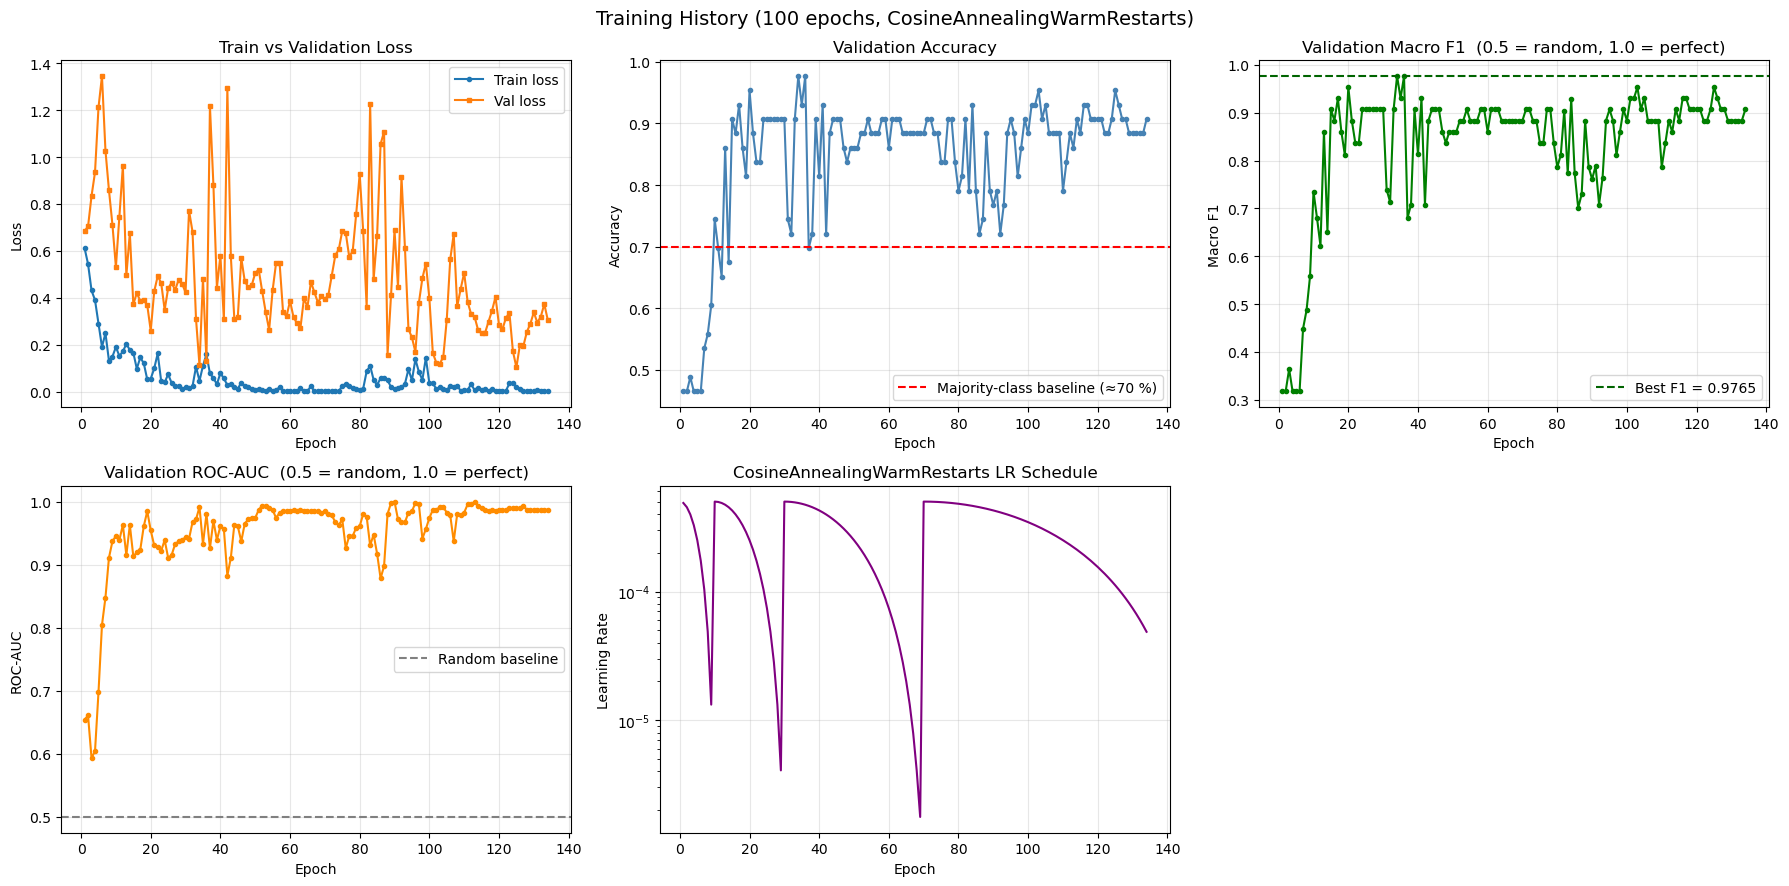

In [48]:
hist = history  # shorthand

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[0].plot(hist["epoch"], hist["train_loss"], marker="o", markersize=3, label="Train loss")
axes[0].plot(hist["epoch"], hist["val_loss"],   marker="s", markersize=3, label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Validation Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Validation Accuracy ───────────────────────────────────────────────────────
axes[1].plot(hist["epoch"], hist["val_acc"], marker="o", markersize=3, color="steelblue")
axes[1].axhline(0.70, linestyle="--", color="red", label="Majority-class baseline (≈70 %)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Macro F1 ─────────────────────────────────────────────────────────────────
axes[2].plot(hist["epoch"], hist["val_f1"], marker="o", markersize=3, color="green")
axes[2].axhline(best_val_f1, linestyle="--", color="darkgreen",
                label=f"Best F1 = {best_val_f1:.4f}")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro F1")
axes[2].set_title("Validation Macro F1  (0.5 = random, 1.0 = perfect)")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

# ── ROC-AUC ──────────────────────────────────────────────────────────────────
axes[3].plot(hist["epoch"], hist["val_auc"], marker="o", markersize=3, color="darkorange")
axes[3].axhline(0.5, linestyle="--", color="grey", label="Random baseline")
axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("ROC-AUC")
axes[3].set_title("Validation ROC-AUC  (0.5 = random, 1.0 = perfect)")
axes[3].legend(); axes[3].grid(True, alpha=0.3)

# ── Learning Rate ─────────────────────────────────────────────────────────────
axes[4].plot(hist["epoch"], hist["lr"], color="purple", lw=1.5)
axes[4].set_xlabel("Epoch"); axes[4].set_ylabel("Learning Rate")
axes[4].set_title("CosineAnnealingWarmRestarts LR Schedule")
axes[4].set_yscale("log")
axes[4].grid(True, alpha=0.3)

# Hide the unused 6th panel
axes[5].axis("off")

plt.suptitle("Training History (100 epochs, CosineAnnealingWarmRestarts)", fontsize=14)
plt.tight_layout()
plt.show()


## Evaluation: Beyond Accuracy

Raw accuracy is misleading on imbalanced data. We use three complementary diagnostics:

| Metric | Why it matters |
|--------|---------------|
| **Confusion matrix** | Shows false negatives (tampered missed) and false positives (standard flagged) separately — clinical costs differ |
| **Precision / Recall / F1** | Unaffected by majority-class size; macro-F1 weighs both classes equally |
| **ROC-AUC** | Measures ranking quality across all decision thresholds; 0.5 = random, 1.0 = perfect |

A model that always predicts "Standard" would score F1 ≈ 0.40 (good Standard class, zero recall for Tampered) and AUC = 0.50.

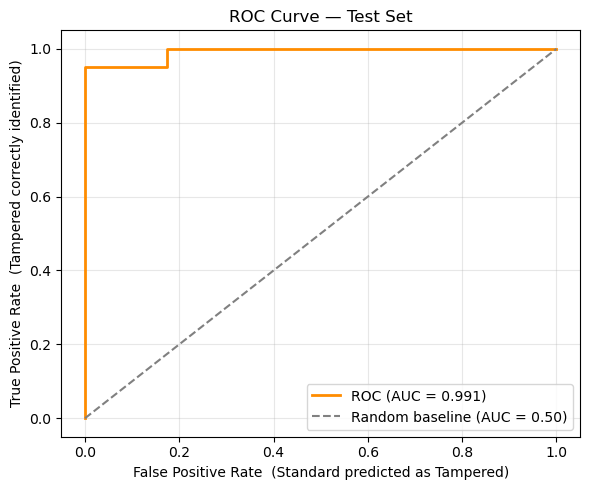

Test ROC-AUC: 0.9913


In [49]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
model.eval()
all_probs_roc: List[float] = []
all_labels_roc: List[int] = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(CFG.device)
        probs = torch.sigmoid(model(xb)).cpu().numpy()
        all_probs_roc.extend(probs.tolist())
        all_labels_roc.extend(yb.numpy().astype(int).tolist())

fpr, tpr, _ = roc_curve(all_labels_roc, all_probs_roc)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, color="darkorange", label=f"ROC (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", lw=1.5, color="grey", label="Random baseline (AUC = 0.50)")
ax.set_xlabel("False Positive Rate  (Standard predicted as Tampered)")
ax.set_ylabel("True Positive Rate  (Tampered correctly identified)")
ax.set_title("ROC Curve — Test Set")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Test ROC-AUC: {roc_auc:.4f}")

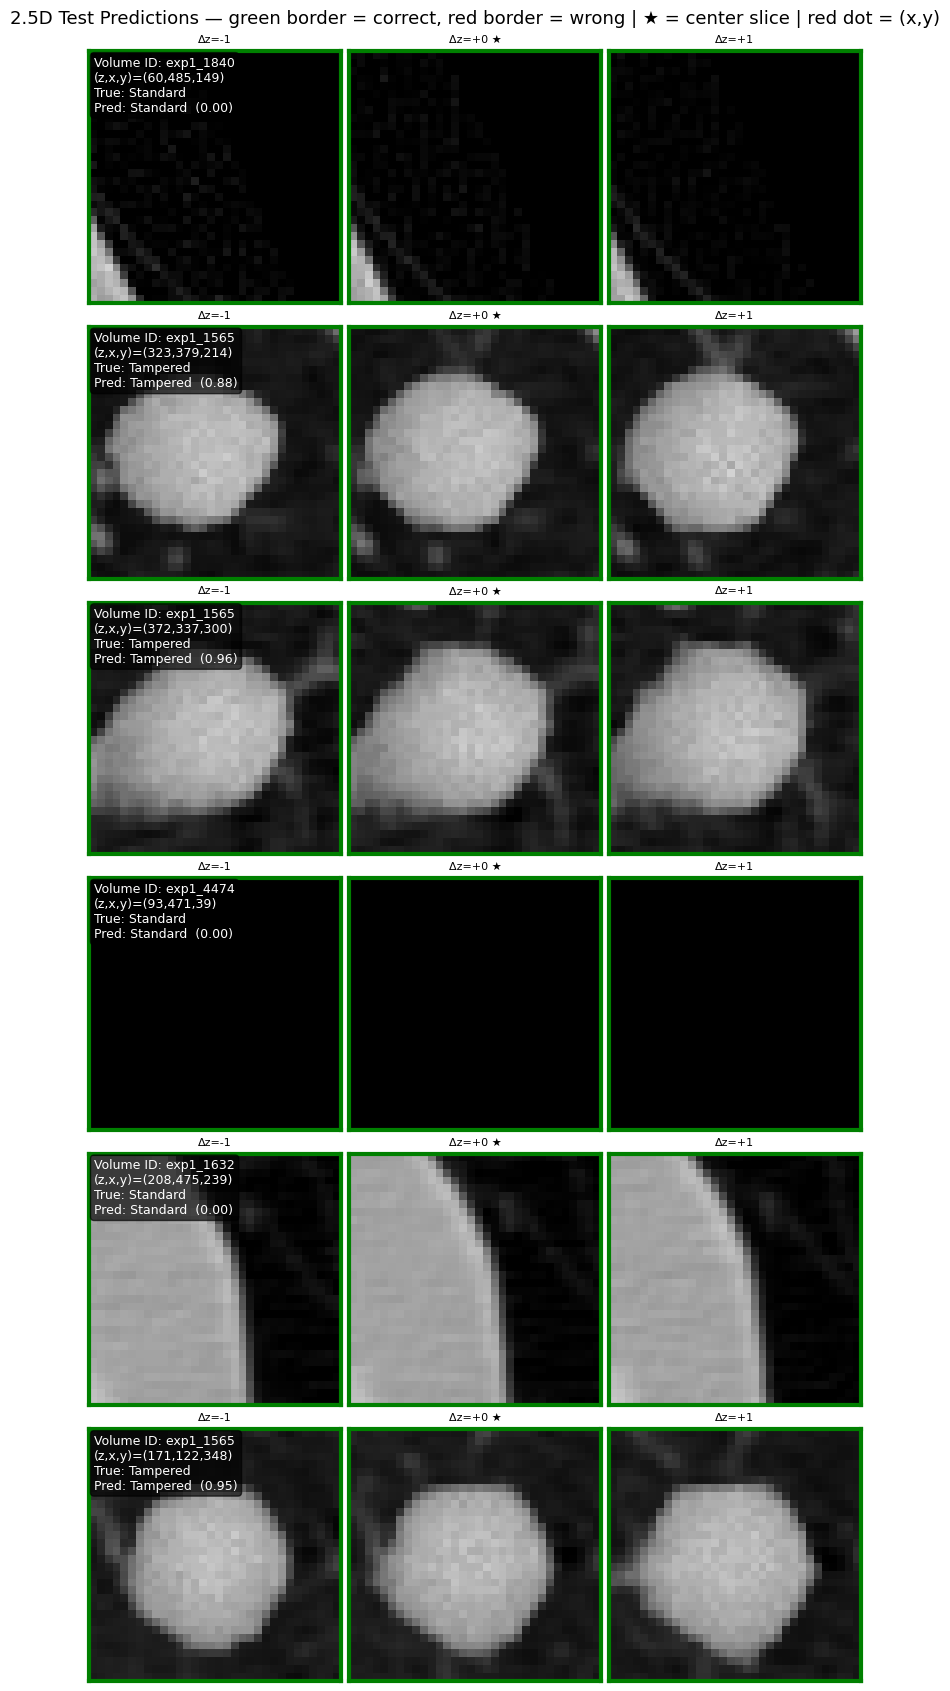

In [50]:
# How many test samples to visualize
n_show = 6
rng = np.random.default_rng(0)
sample_idxs = rng.choice(len(test_ds), size=n_show, replace=False)

K = CFG.k_slices
center_k = K // 2
hs = CFG.patch_size // 2  # patch center (x,y) inside the cropped patch

fig, axes = plt.subplots(
    n_show, K,
    figsize=(2.6 * K, 2.8 * n_show),
    constrained_layout=True
)

# Make axes always 2D
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)
if K == 1:
    axes = np.expand_dims(axes, axis=1)

model.eval()

for row_i, idx in enumerate(sample_idxs):
    # x: (K, P, P), y: scalar 0/1
    x, y_true = test_ds[int(idx)]
    true_int = int(y_true.item())

    # Pull metadata from dataset CSV (same row order as dataset)
    meta = test_ds.df.iloc[int(idx)]
    source = str(meta["source"])
    uuid = str(meta["uuid"])
    volume_id = f"{source}_{uuid}"
    zc = int(meta["slice"])
    xc = int(meta["x"])
    yc = int(meta["y"])

    with torch.no_grad():
        prob = torch.sigmoid(model(x.unsqueeze(0).to(CFG.device))).item()

    pred_int = int(prob >= 0.5)
    correct = (pred_int == true_int)

    true_str = "Tampered" if true_int else "Standard"
    pred_str = "Tampered" if pred_int else "Standard"

    # Very visible row color
    row_color = "green" if correct else "red"

    for k in range(K):
        ax = axes[row_i, k]
        img = x[k].cpu().numpy()

        ax.imshow(img, cmap="gray", vmin=0, vmax=1)

        # ★ on center slice
        title = f"Δz={k-center_k:+d}" + (" ★" if k == center_k else "")
        ax.set_title(title, fontsize=8)

        # Color-code correctness using borders/spines (this is super obvious)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(3.0)
            spine.set_edgecolor(row_color)

        ax.set_xticks([])
        ax.set_yticks([])

    # Put a labeled text box inside the first panel of the row
    ax0 = axes[row_i, 0]
    info = (
        f"Volume ID: {volume_id}\n"
        f"(z,x,y)=({zc},{xc},{yc})\n"
        f"True: {true_str}\n"
        f"Pred: {pred_str}  ({prob:.2f})"
    )
    ax0.text(
        0.02, 0.98, info,
        transform=ax0.transAxes,
        ha="left", va="top",
        fontsize=9,
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.65)
    )

plt.suptitle(
    "2.5D Test Predictions — green border = correct, red border = wrong | ★ = center slice | red dot = (x,y)",
    fontsize=13
)
plt.show()

Total misclassifications on test set: 1 / 43
  False Positives (Standard predicted as Tampered): 0
  False Negatives (Tampered predicted as Standard): 1
No False Positives — Standard patches called Tampered errors to display.


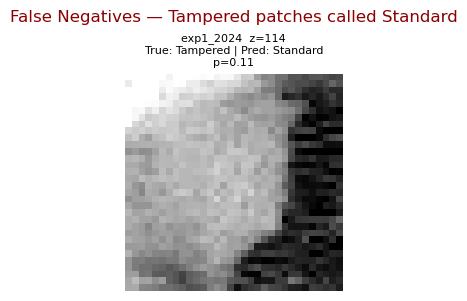

In [51]:
# ── Visualise ALL misclassified test examples (2.5D) ─────────────────────────
model.eval()
misclassified: List[Dict] = []

K = CFG.k_slices
center_k = K // 2
hs = CFG.patch_size // 2  # red dot at patch center

with torch.no_grad():
    global_idx = 0  # maps into test_ds order IF test_loader shuffle=False
    for xb, yb in test_loader:
        xb_dev = xb.to(CFG.device)                 # (B, K, P, P)
        probs_batch = torch.sigmoid(model(xb_dev)).cpu().numpy()   # (B,)
        preds_batch = (probs_batch >= 0.5).astype(int)
        labels_batch = yb.cpu().numpy().astype(int)

        B = len(labels_batch)
        for i in range(B):
            if preds_batch[i] != labels_batch[i]:
                ds_idx = global_idx + i

                # Center slice patch for visualization: (P, P)
                patch2d = xb[i, center_k].cpu().numpy()

                # Metadata from dataset dataframe
                meta = test_ds.df.iloc[ds_idx]
                source = str(meta["source"])
                uuid = str(meta["uuid"])
                volume_id = f"{source}_{uuid}"
                zc = int(meta["slice"])
                xc = int(meta["x"])
                yc = int(meta["y"])

                misclassified.append({
                    "ds_idx": ds_idx,
                    "uuid": uuid,
                    "volume_id": volume_id,
                    "z": zc, "x": xc, "y": yc,
                    "patch": patch2d,
                    "true": int(labels_batch[i]),
                    "pred": int(preds_batch[i]),
                    "prob": float(probs_batch[i]),
                })

        global_idx += B

print(f"Total misclassifications on test set: {len(misclassified)} / {len(test_ds)}")

false_positives = [m for m in misclassified if m["true"] == 0 and m["pred"] == 1]
false_negatives = [m for m in misclassified if m["true"] == 1 and m["pred"] == 0]
print(f"  False Positives (Standard predicted as Tampered): {len(false_positives)}")
print(f"  False Negatives (Tampered predicted as Standard): {len(false_negatives)}")

def _plot_error_grid(cases: List[dict], title: str, max_show: int = 24):
    if not cases:
        print(f"No {title} errors to display.")
        return

    show = cases[:max_show]
    cols = min(6, len(show))
    rows = (len(show) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(2.7 * cols, 2.9 * rows), constrained_layout=True)
    axes_flat = np.array(axes).ravel() if rows * cols > 1 else np.array([axes])

    for ax, m in zip(axes_flat, show):
        ax.imshow(m["patch"], cmap="gray", vmin=0, vmax=1)
        
        true_str = "Tampered" if m["true"] == 1 else "Standard"
        pred_str = "Tampered" if m["pred"] == 1 else "Standard"

        ax.set_title(
            f"{m['volume_id']}  z={m['z']}\n"
            f"True: {true_str} | Pred: {pred_str}\n"
            f"p={m['prob']:.2f}",
            fontsize=8
        )
        ax.axis("off")

    # hide unused axes
    for ax in axes_flat[len(show):]:
        ax.axis("off")

    extra = f"  (+{len(cases) - max_show} more)" if len(cases) > max_show else ""
    plt.suptitle(f"{title}{extra}", fontsize=12, color="darkred")
    plt.show()

_plot_error_grid(false_positives, "False Positives — Standard patches called Tampered")
_plot_error_grid(false_negatives, "False Negatives — Tampered patches called Standard")

In [52]:
# ── Final evaluation on entire train and test sets ───────────────────────────
_, final_train_acc, final_train_f1, final_train_auc = evaluate(model, train_loader, criterion, CFG.device)
_, final_test_acc,  final_test_f1,  final_test_auc  = evaluate(model, test_loader,  criterion, CFG.device)

print("=" * 54)
print(f"{'Metric':<22} {'Train':>10} {'Test':>10}")
print("-" * 54)
print(f"{'Accuracy':<22} {final_train_acc:>10.4f} {final_test_acc:>10.4f}")
print(f"{'Macro F1':<22} {final_train_f1:>10.4f} {final_test_f1:>10.4f}")
print(f"{'ROC-AUC':<22} {final_train_auc:>10.4f} {final_test_auc:>10.4f}")
print("=" * 54)

majority_baseline = max(
    (work_df["target"] == 0).mean(),
    (work_df["target"] == 1).mean(),
)
print(f"\nMajority-class accuracy baseline : {majority_baseline:.4f}")
print(f"Model test accuracy               : {final_test_acc:.4f}  "
      + ("✓ beats baseline" if final_test_acc > majority_baseline else "✗ does not beat baseline"))
print(f"Model test macro F1               : {final_test_f1:.4f}  "
      + ("✓ above random (0.50)" if final_test_f1 > 0.50 else "✗ not above random"))

Metric                      Train       Test
------------------------------------------------------
Accuracy                   0.9611     0.9767
Macro F1                   0.9603     0.9765
ROC-AUC                    0.9983     0.9913

Majority-class accuracy baseline : 0.5067
Model test accuracy               : 0.9767  ✓ beats baseline
Model test macro F1               : 0.9765  ✓ above random (0.50)
